In [1]:
# Importing the necessary libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp

In [2]:
# Chemical constant
k1 = 3e-9
k1_ref = 1e-18
k2 = 1e-13
k2_ref = 1e-13
k3 = 1e-15
krdp = 1e-10
k4 = 0
k5 = 0
kdet_ref = 1.3e-21
alpha_4 = 0.5
rho_cc = 2.26
Mcc = 12.01
Ueq_4 = 0.2
Vm_Pt = 9.09  # Molar volume of Pt cm3/mol
M_Pt = 195.0849  # Molar mass of platinum (g/mol)
F = 96485  # C. mol-1. It is the Faraday constant.
R = 8.314  # J. mol-1.K-1. It is the universal gas constant.

# Dynamic parameters
Cpt2_ref = 1e-3
rho_Pt = 21.45  # Density of platinum g/cm^3
GAMMA_max = 2.18e-9 # GAMMA(strong assumption): The active site quantity in moles per platinum area (mole/cm^2)

In [3]:
def PtOxideDissolution(theta, Ch):

    return k3 * theta * Ch ** 2

def PtDissolution(Ucell, T_fc, Cpt2, theta):

    alpha_1 = 0.5
    Ueq_1 = 1.15  # Standard equilibrium potential Ueq_1
    n = 2  # Electron transferred
    # Modelled as Butler-Volmer equation
    Rf = np.exp((alpha_1 * F * n) / (R * T_fc) * (Ucell - Ueq_1))  # Forward
    Rb = Cpt2 / Cpt2_ref * np.exp((-(1 - alpha_1) * F * n) / (R * T_fc) * (Ucell - Ueq_1))  # Reverse
    return k1 * (1 - theta) * Rf - k1_ref * Rb

def PtOxidation(Ucell, T_fc, Ch, theta):

    # Standard equilibrium potential Ueq_2
    Ueq_2 = 0.97
    n = 2
    alpha_2 = 0.5
    omega = 27e3
    Ch_ref = 1e-3

    Rf = (k2 * np.exp(-omega * theta / (R * T_fc)) *
          np.exp((alpha_2 * F * n) / (R * T_fc) * (Ucell - Ueq_2)))
    Rb = (k2_ref * theta * (Ch / Ch_ref) ** 2 *
          np.exp((-alpha_2 * F * n) / (R * T_fc) * (Ucell - Ueq_2)))

    return Rf - Rb

def PtDetachment(Ucell, T_fc, r):

    n = 2
    return kdet_ref * Mcc / rho_cc * np.exp((alpha_4 * F * n) / (R * T_fc) * (Ucell - Ueq_4)) / r

In [4]:
# Global variables
n_group_ptParticle = 50
rmin = 1e-8
rmax = 1e-6
dr = 1e-6 / n_group_ptParticle
r_m = (np.linspace(rmin, rmax, n_group_ptParticle + 1) + dr / 2)[1:]
Tfc = 273.15+80

In [5]:
def initPRD(resolution=100, rmin=1e-8, rmax=1e-6, std=0.549, mu=0.538):
    
    radius = np.linspace(rmin, rmax, resolution)
    pdf = 1/(std*np.sqrt(4*np.pi)) * np.exp(-(np.log(radius*1e7)-mu)**2/(std**2*2))
    return pdf

def ucell_sw(t):
    
    t = t%6
    t_stop = 6
    iload_rise =  0.2 * np.tanh(8*(t - t_stop / 4)) + 0.3
    iload_drop =  -0.2 * np.tanh(8*(t - t_stop * 3 / 4)) +0.3
    return iload_rise  + iload_drop

def ucell_tw(t):
    
    t = t%6
    UPL = 0.95
    LPL = 0.60
    v_scan = 0.125
    u = (UPL-LPL)/np.pi*np.arcsin(np.sin((np.pi*v_scan)/(UPL-LPL)*t-np.pi/2))+(UPL-LPL)/2+LPL
    return u

Text(0, 0.5, 'Density')

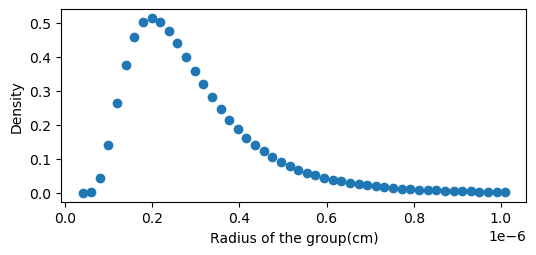

In [6]:
plt.figure(figsize=(6,2.5))
plt.scatter(r_m,initPRD(50))
plt.xlabel("Radius of the group(cm)")
plt.ylabel("Density")

Text(0, 0.5, 'Ucell')

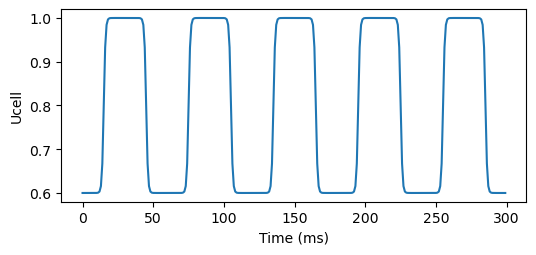

In [7]:
fig, ax = plt.subplots(figsize=(6,2.5))
ax.plot(ucell_sw(np.arange(0,30,0.1)))
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Ucell")

In [8]:
def Cproton_CCL(lambda_w, EW=1.1, rho_mem=0.002):
    
    rho_H2O = 997  # (kg/m3)
    M_H2O = 18.02e-3  # kg/mol
    return 1 / ((EW / rho_mem) + lambda_w * (M_H2O / rho_H2O))

class ccl():
    
    def __init__(self):
        
        self.Ucell = ucell_tw
        self.prd0 = initPRD(resolution=n_group_ptParticle)
        
    def dxdt(self, t, x):
            
        C_Pt2_ccl = x[0]
        theta_CCL = x[1:1+len(r_m)]
        prd = x[-len(r_m):]
        u = self.Ucell(t)
        
        # CCL kinetic
        # 0.043 + 17.81*0.85 - 39.85*0.85**2 + 36*0.85**3 = 8.5
        R0 = (2*9.09*0.2e-4)/(R*353)
        C_H_CCL = Cproton_CCL(lambda_w=8.5)
        kdis = PtDissolution(u, Tfc, C_Pt2_ccl, theta_CCL)
        kox = PtOxidation(u, Tfc, C_H_CCL, theta_CCL)
        kcdis = PtOxideDissolution(theta_CCL, C_H_CCL)
        kdet = PtDetachment(u, Tfc, r_m)
        drdt = Vm_Pt * krdp * C_Pt2_ccl * np.exp(-R0 / r_m) - Vm_Pt * (kdis + kox) * Cpt2_ref * np.exp(R0 / r_m)
        M_Pt0 = 4 / 3 * np.pi * rho_Pt * np.trapz(y=self.prd0 * r_m ** 3, x=r_m)

        dMdisdt = 4 * np.pi * rho_Pt * np.trapz(y=prd * r_m ** 2 * drdt, x=r_m)
        dMcdisdt = 4 * np.pi * rho_Pt * np.trapz(y=prd * r_m ** 2 * kcdis, x=r_m)
        
        dC_Pt2_ccl = -3.33 / M_Pt * (dMdisdt - dMcdisdt) / M_Pt0
        dfdt = -np.gradient(prd * drdt, r_m) - kdet * prd
        dthetadt = (((kox - kcdis) / GAMMA_max) - (2 * theta_CCL / r_m) * drdt)
        
        dxdt = [0]*(1+len(r_m)*2)
        dxdt[0] = dC_Pt2_ccl
        dxdt[1:1+len(r_m)] = dthetadt
        dxdt[-len(r_m):] = dfdt
        
        return dxdt

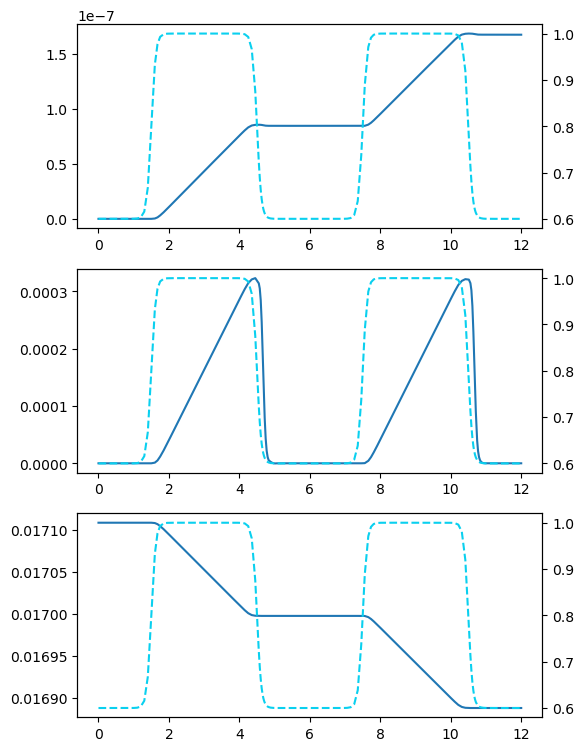

In [9]:
model = ccl()
model.Ucell = ucell_sw
x_init = [0] + [0]*len(r_m) + model.prd0.tolist()
sol = solve_ivp(fun=model.dxdt, y0 = x_init, t_span=(0, 12),max_step=1e-1, method='BDF')
fig, ax = plt.subplots(nrows=3,ncols=1,figsize=(6,9))
ax[0].plot(sol.t, sol.y[0,:])
ax_twin = ax[0].twinx()
ax_twin.plot(sol.t, [ucell_sw(t) for t in sol.t], color = '#0AD0EF', linestyle = '--')
ax[1].plot(sol.t, sol.y[35,:])
ax_twin = ax[1].twinx()
ax_twin.plot(sol.t, [ucell_sw(t) for t in sol.t], color = '#0AD0EF', linestyle = '--')
ax[2].plot(sol.t, sol.y[-15,:])
ax_twin = ax[2].twinx()
ax_twin.plot(sol.t, [ucell_sw(t) for t in sol.t], color = '#0AD0EF', linestyle = '--')


In [10]:
model = ccl()
x_init = [0] + [0]*len(r_m) + model.prd0.tolist()
sol_hist = []
for i_cycle in range(7):
    sol = solve_ivp(fun=model.dxdt, y0 = sol.y[:,-1], t_span=(0, 5000*6), method='BDF')
    print(str(i_cycle)+f", ECSA = {(np.trapz(y=(r_m ** 2) * sol.y[-50:,-1], x=r_m))/(np.trapz(y=(r_m ** 2) * model.prd0, x=r_m))}")
    sol_hist.append(sol)

0, ECSA = 0.9372941116701625
1, ECSA = 0.7992128953646922
2, ECSA = 0.6620767570056851
3, ECSA = 0.593020455136583
4, ECSA = 0.46601997769595893
5, ECSA = 0.46272437151280554
6, ECSA = 0.4056512040098964


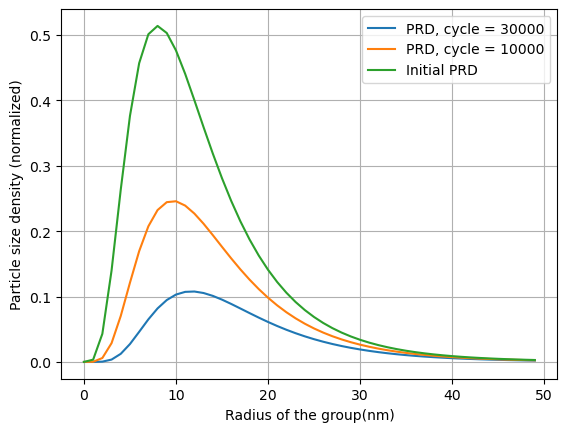

In [11]:
plt.figure()
plt.ylabel("Particle size density (normalized)")
plt.xlabel("Radius of the group(nm)")
plt.plot(sol_hist[-1].y[-50:,-1], label = "PRD, cycle = 30000")
plt.plot(sol_hist[2].y[-50:,-1], label = "PRD, cycle = 10000")
plt.plot(model.prd0, label = "Initial PRD")
plt.grid()
plt.legend()

In [12]:
exp_data = [1, 0.71,0.69,0.595,0.61,0.58,0.39]

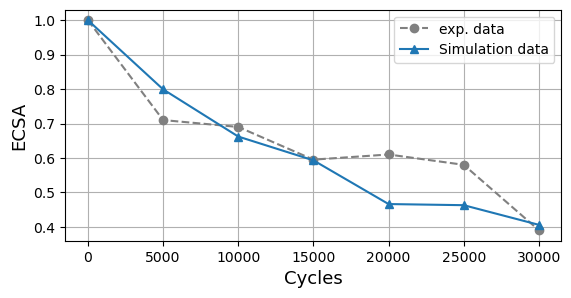

In [13]:
plt.figure(figsize=(6.4,3))
plt.plot([x*5000 for x in range(7)],exp_data, linestyle='--', marker='o', label = "exp. data", color = "grey")
plt.plot([x*5000 for x in range(7)],[1]+[(np.trapz(y=(r_m ** 2) * sol_hist[i_sol+1].y[-len(r_m):,-1], x=r_m))/(np.trapz(y=(r_m ** 2) * model.prd0, x=r_m)) for i_sol in range(len(sol_hist)-1)], label = "Simulation data", marker = "^")
plt.legend()
plt.xlabel("Cycles",fontsize=13)
plt.ylabel("ECSA",fontsize=13)
plt.grid()

In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK, STATUS_FAIL
 
# Experimental ECSA decay (from cell 11 of the notebook)
exp_data  = np.array([1.0, 0.71, 0.69, 0.595, 0.61, 0.58, 0.39])
cycles_x  = np.array([5000 * i for i in range(7)])             # x-axis: cycles
 
# Reference ECSA denominator (initial particle radius distribution)
_prd0     = initPRD(resolution=n_group_ptParticle)
ECSA_REF  = np.trapz(y=(r_m ** 2) * _prd0, x=r_m)
 
# Number of outer iterations to match the last figure exactly:
#   plotted indices are sol_hist[1] .. sol_hist[6]  (6 points)  +  the trivial 1.0
# So the optimiser needs 6 inner solve_ivp calls per evaluation.
N_OUTER = 6
 
 
# %% ---------- Cell B: simulation wrapper + hyperopt objective --------------
def simulate_ecsa(k1_v, k2_v, k3_v, krdp_v, n_outer=N_OUTER):
    """Run the ECSA AST simulation with the given kinetic constants and return
    the ECSA trajectory [1.0, e1, e2, ..., e_n_outer] (length n_outer+1)."""
    # Patch module-level globals consumed by the kinetic functions and dxdt.
    global k1, k2, k3, krdp
    k1, k2, k3, krdp = k1_v, k2_v, k3_v, krdp_v
 
    model  = ccl()                                 # default Ucell = ucell_tw (AST)
    y_last = np.array([0.0] + [0.0] * len(r_m) + model.prd0.tolist())
 
    ecsa_hist = [1.0]
    for _ in range(n_outer):
        sol = solve_ivp(fun=model.dxdt, y0=y_last,
                        t_span=(0, 5000 * 6), method='BDF')
        if not sol.success:
            raise RuntimeError(f"solve_ivp failed: {sol.message}")
        y_last   = sol.y[:, -1]
        prd_last = y_last[-len(r_m):]
        ecsa_hist.append(np.trapz(y=(r_m ** 2) * prd_last, x=r_m) / ECSA_REF)
    return np.array(ecsa_hist)
 
 
_eval_log = []   # one entry per evaluation, kept for plotting / diagnostics
 
def objective(params):
    t0 = time.time()
    try:
        ecsa_sim = simulate_ecsa(params['k1'], params['k2'],
                                 params['k3'], params['krdp'])
        if np.any(np.isnan(ecsa_sim)) or np.any(ecsa_sim < 0) or np.any(ecsa_sim > 1.5):
            raise ValueError("non-physical ECSA values")
        # Drop the trivial point 0 (always 1.0 by construction) from the loss.
        loss   = float(np.mean((ecsa_sim[1:] - exp_data[1:]) ** 2))
        status = STATUS_OK
    except Exception as e:
        ecsa_sim = None
        loss     = 1.0           # large but finite -> TPE will avoid this region
        status   = STATUS_FAIL
 
    dt = time.time() - t0
    _eval_log.append({'params': params, 'loss': loss, 'status': status,
                      'ecsa_sim': None if ecsa_sim is None else ecsa_sim.tolist(),
                      'wall_s': dt})
    print(f"#{len(_eval_log):3d}  loss={loss:.5f}  "
          f"k1={params['k1']:.2e}  k2={params['k2']:.2e}  "
          f"k3={params['k3']:.2e}  krdp={params['krdp']:.2e}  "
          f"({dt:5.1f}s, {status})")
    return {'loss': loss, 'status': status}
 
 
# %% ---------- Cell C: run the optimisation ---------------------------------
# Search space: log-uniform, ~2 orders of magnitude either side of the
# notebook's starting values (k1=3e-9, k2=1e-13, k3=1e-15, krdp=1e-10).
# Tighten these once you see where TPE concentrates its samples.
space = {
    'k1':   hp.loguniform('k1',   np.log(1e-11), np.log(1e-7 )),
    'k2':   hp.loguniform('k2',   np.log(1e-15), np.log(1e-11)),
    'k3':   hp.loguniform('k3',   np.log(1e-17), np.log(1e-13)),
    'krdp': hp.loguniform('krdp', np.log(1e-12), np.log(1e-8 )),
}
 
trials = Trials()
best = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=40,                                  # raise once you know it runs
    trials=trials,
    rstate=np.random.default_rng(0),
    show_progressbar=False,
)
print("\nBest parameters found by hyperopt:")
for k, v in best.items():
    print(f"  {k:5s} = {v:.4e}")
 
 
# %% ---------- Cell D: visualise the fit and the search history -------------
ecsa_best = simulate_ecsa(best['k1'], best['k2'], best['k3'], best['krdp'])
 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
 
# (1) ECSA fit
axes[0].plot(cycles_x, exp_data,  'o--', color='grey', label='Experimental')
axes[0].plot(cycles_x, ecsa_best, '^-',  color='C0',   label='Simulation (best)')
axes[0].set_xlabel('Cycles')
axes[0].set_ylabel(r'ECSA / ECSA$_0$')
axes[0].set_title(
    f"k1={best['k1']:.2e}   k2={best['k2']:.2e}\n"
    f"k3={best['k3']:.2e}   krdp={best['krdp']:.2e}",
    fontsize=10,
)
axes[0].grid(); axes[0].legend()
 
# (2) Loss vs. evaluation
losses_all  = [t['result']['loss'] for t in trials.trials]
losses_best = np.minimum.accumulate(losses_all)
axes[1].plot(losses_all,  '.', alpha=0.4, label='per-evaluation loss')
axes[1].plot(losses_best, 'r-',           label='best so far')
axes[1].set_xlabel('Evaluation #')
axes[1].set_ylabel('MSE loss')
axes[1].set_yscale('log')
axes[1].grid(); axes[1].legend()
 
plt.tight_layout()
plt.show()

#  1  loss=0.00374  k1=2.19e-08  k2=5.78e-15  k3=5.72e-17  krdp=5.36e-10  (  6.8s, ok)
#  2  loss=0.02740  k1=1.88e-09  k2=5.64e-15  k3=1.27e-16  krdp=2.03e-09  (  7.1s, ok)
#  3  loss=0.01109  k1=3.13e-10  k2=4.37e-14  k3=6.47e-15  krdp=5.87e-11  ( 28.9s, ok)
